# Diversity assessment

## Foreword

## 1. Import libraries

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl
import seaborn as sns
from scipy.stats import kruskal
import scikit_posthocs as sp
from inventory_data import load_inventory

## 2. Data import and tidying

In [47]:
df = load_inventory()

## 3. Speciation curves

In [48]:
# 1. Group by 'Line Number' and 'Plot'
# 2. Count unique 'Scientific name' in each group
species_per_plot = df.groupby(["Line Number", "Plot"], observed=True)["Scientific name"].nunique().reset_index()

# Rename the column for clarity
species_per_plot.columns = ["Line Number", "Plot", "Species Count"]

# Display the result
print(species_per_plot)

   Line Number Plot  Species Count
0            1    1             36
1            1    2             37
2            1    3             30
3            1    4             45
4            1    5             32
..         ...  ...            ...
84           7   85             36
85           7   86             32
86           7   87             23
87           7   88             31
88           7   89             36

[89 rows x 3 columns]


In [49]:
# 1. Aggregate unique scientific names into sets for each (Line Number, Plot)
species_per_plot = (
    df.groupby(["Line Number", "Plot"], observed=True)["Scientific name"]
    .unique()
    .apply(set)
    .reset_index()
)

# 2. Ensure sorting
species_per_plot = species_per_plot.sort_values(["Line Number", "Plot"])

# 3. Define function for "First-time Discovery" only
def count_unique_non_repeating_in_line(group):
    seen_species = set()  # Keeps track of everything seen in the line so far
    unique_new_counts = []
    
    for current_plot_species in group["Scientific name"]:
        # Species in this plot MINUS everything we saw in previous plots of this line
        new_species = current_plot_species - seen_species
        
        unique_new_counts.append(len(new_species))
        
        # Update the 'seen' set with the species from the current plot
        seen_species.update(current_plot_species)
            
    group["Tree species"] = unique_new_counts
    return group

# 4. Apply the logic independently per Line
final_counts = (
    species_per_plot.groupby("Line Number", observed=True)
    .apply(count_unique_non_repeating_in_line)
    .reset_index(drop=True)
)

result_table = final_counts[["Line Number", "Plot", "Tree species"]]
print(result_table)

   Line Number Plot  Tree species
0            1    1            36
1            1    2            10
2            1    3             2
3            1    4            14
4            1    5             3
..         ...  ...           ...
84           7   85             3
85           7   86             9
86           7   87             0
87           7   88             3
88           7   89             5

[89 rows x 3 columns]


C:\Users\migue\AppData\Local\Temp\ipykernel_21232\532683289.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(count_unique_non_repeating_in_line)


In [50]:
# 1. Reuse the logic from the previous step to get the 'final_counts' dataframe
# (Assuming 'final_counts' contains: Line Number, Plot, New Scientific Names)

# 2. Calculate the Cumulative New Species and Cumulative Area per Line
# We use groupby to ensure cumulative counts don't bleed between lines
final_counts["Accumulated Tree species"] = (
    final_counts.groupby("Line Number", observed=True)["Tree species"]
    .cumsum()
)

# 3. Calculate Accumulated Area (Plot area = 0.5 ha)
# We count the plots processed so far in each line and multiply by 0.5
final_counts["Accumulated Area [ha]"] = (
    final_counts.groupby("Line Number", observed=True).cumcount() + 1
) * 0.5

# 4. Sort the result by "Tree species" in descending order
sorted_results = final_counts.sort_values(
    by="Tree species", 
    ascending=False
)

# 5. Display the final table
print(sorted_results[[
    "Line Number", 
    "Plot", 
    "Tree species", 
    "Accumulated Tree species", 
    "Accumulated Area [ha]"
]])

   Line Number Plot  Tree species  Accumulated Tree species  \
66           6   67            42                        42   
49           4   50            37                        37   
0            1    1            36                        36   
31           3   32            35                        35   
78           7   79            35                        35   
..         ...  ...           ...                       ...   
76           6   77             0                        77   
77           6   78             0                        77   
73           6   74             0                        74   
74           6   75             0                        74   
86           7   87             0                        71   

    Accumulated Area [ha]  
66                    0.5  
49                    0.5  
0                     0.5  
31                    0.5  
78                    0.5  
..                    ...  
76                    5.5  
77                 

C:\Users\migue\AppData\Local\Temp\ipykernel_21232\2898570313.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for line_id, group in sorted_results.groupby("Line Number"):


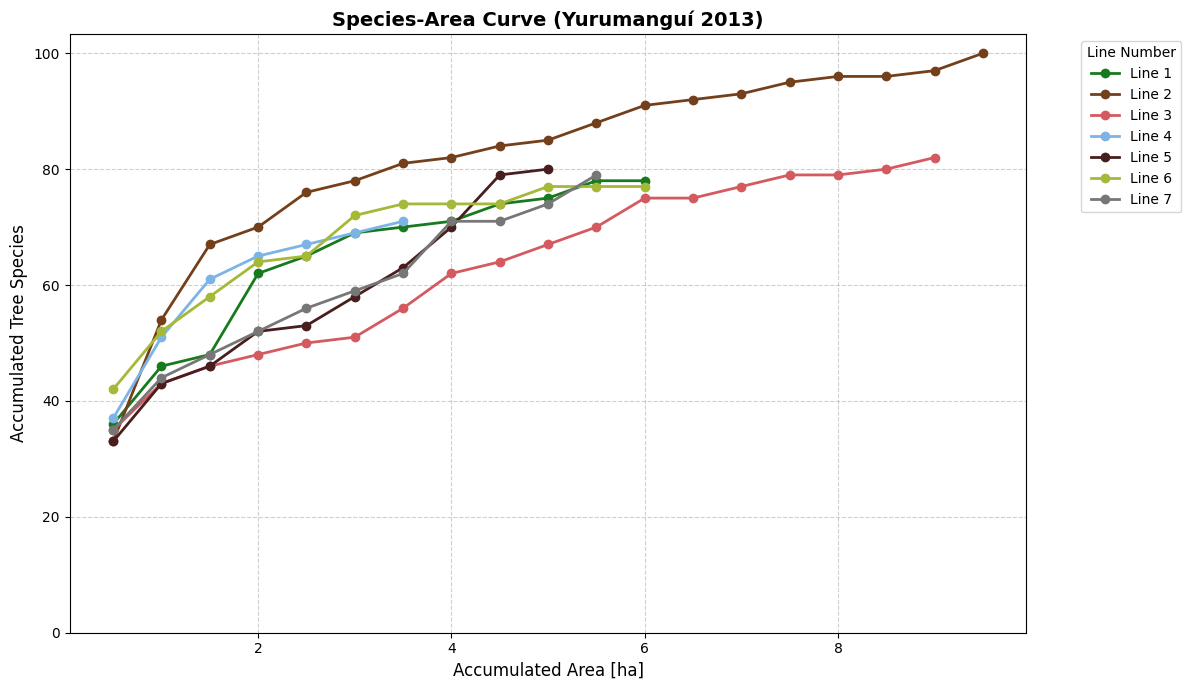

In [51]:
# Your color dictionary
dict_line = {
    1: "#187a1e",
    2: "#74401b",
    3: "#d45a60",
    4: "#7db4e6",
    5: "#481e1e",
    6: "#a5b837",
    7: "#777777",
}

# 5. Visualization: Species-Area Curve with Custom Colors
plt.figure(figsize=(12, 7))

# Ensure Line Number is treated as an integer for the dictionary lookup
for line_id, group in sorted_results.groupby("Line Number"):
    # Sort group by area to ensure the line plots correctly
    plot_group = group.sort_values("Accumulated Area [ha]")
    
    # Get color from dictionary (defaults to black if ID is missing)
    line_color = dict_line.get(int(line_id), "black")
    
    plt.plot(
        plot_group["Accumulated Area [ha]"], 
        plot_group["Accumulated Tree species"], 
        marker='o', 
        linestyle='-', 
        linewidth=2,
        markersize=6,
        label=f'Line {line_id}',
        color=line_color
    )

# Formatting the plot
plt.title("Species-Area Curve (Yurumanguí 2013)", fontsize=14, fontweight='bold')
plt.xlabel("Accumulated Area [ha]", fontsize=12)
plt.ylabel("Accumulated Tree Species", fontsize=12)
plt.ylim(bottom=0)
# Place legend outside of the plot area for better visibility
plt.legend(title="Line Number", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 4. Diversity indexes

### 4.1 Richness

In [52]:
# We use observed=True because your columns are categorical
species_per_line = (
    df.groupby(["Line Number"], observed=True)["Scientific name"]
    .nunique()
    .reset_index(name="Tree species")
)

species_per_line["Number of trees"] = df.groupby("Line Number", observed=True)["Tree number"].nunique().values
print(species_per_line)

  Line Number  Tree species  Number of trees
0           1            78              257
1           2            99              275
2           3            82              237
3           4            71              150
4           5            80              130
5           6            77              211
6           7            79              153


#### 4.1.1 Margalef

$$ D_{Mg}=\frac{S-1}{\ln(N)}

In [53]:
species_per_line["Margalef Index"] = (species_per_line["Tree species"] - 1) / np.log(species_per_line["Number of trees"])
print(species_per_line)

  Line Number  Tree species  Number of trees  Margalef Index
0           1            78              257       13.876184
1           2            99              275       17.447747
2           3            82              237       14.813297
3           4            71              150       13.970284
4           5            80              130       16.229983
5           6            77              211       14.200675
6           7            79              153       15.505608


#### 4.1.2 Menhinick

$$ D_{Mn}=\frac{S}{\sqrt{N}}

In [54]:
species_per_line["Menhinick Index"] = (species_per_line["Tree species"]) / np.sqrt(species_per_line["Number of trees"])
print(species_per_line)

  Line Number  Tree species  Number of trees  Margalef Index  Menhinick Index
0           1            78              257       13.876184         4.865506
1           2            99              275       17.447747         5.969925
2           3            82              237       14.813297         5.326472
3           4            71              150       13.970284         5.797126
4           5            80              130       16.229983         7.016464
5           6            77              211       14.200675         5.300899
6           7            79              153       15.505608         6.386771


#### 4.1.3 Holdridge

### 4.2 Alpha-diversity

#### 4.2.1 Shannon-Wiener

$$ H'=-\sum_{}^{}p_{i}\ln(p_{i}) $$

$$ p_{i} = \frac{n_{i}}{N} $$

$$ E =\frac{H'}{\ln(S)} $$

In [55]:
abundance_per_line_per_sp = (
    df.groupby(["Line Number", "Scientific name"], observed=True)["Tree number"]
    .nunique()
    .reset_index(name="Number of trees")
)

abundance_per_line_per_sp["Relative abundance"] = (
    abundance_per_line_per_sp["Number of trees"] / 
    abundance_per_line_per_sp.groupby("Line Number")["Number of trees"].transform('sum')
)

abundance_per_line_per_sp["Shannon Index Component"] = (
    - abundance_per_line_per_sp["Relative abundance"] *np.log(abundance_per_line_per_sp["Relative abundance"])
)

print(abundance_per_line_per_sp)

    Line Number           Scientific name  Number of trees  \
0             1         Aegiphila grandis                1   
1             1       Anacardium excelsum               30   
2             1             Apeiba aspera                7   
3             1  Astrocaryum standleyanum                9   
4             1      Basiloxylon excelsum                1   
..          ...                       ...              ...   
561           7               Vatairea sp               14   
562           7                Virola spp               36   
563           7                Xilopia sp                9   
564           7    Zanthoxylon rhoifolium                2   
565           7                        nn               42   

     Relative abundance  Shannon Index Component  
0              0.000565                 0.004223  
1              0.016940                 0.069081  
2              0.003953                 0.021871  
3              0.005082                 0.026843  


C:\Users\migue\AppData\Local\Temp\ipykernel_21232\3671354800.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  abundance_per_line_per_sp.groupby("Line Number")["Number of trees"].transform('sum')


In [56]:
shannon_index_per_line = (
    abundance_per_line_per_sp.groupby("Line Number", observed=True)["Shannon Index Component"]
    .sum()
    .reset_index(name="Shannon Index")
)

print(shannon_index_per_line)

  Line Number  Shannon Index
0           1       3.600484
1           2       3.856282
2           3       3.754718
3           4       3.744202
4           5       3.664648
5           6       3.771379
6           7       3.805867


In [57]:
lines = species_per_line['Line Number']
species = species_per_line['Tree species']
trees = species_per_line['Number of trees']
margalef = pd.to_numeric(species_per_line['Margalef Index'], errors='coerce')
menhinick = pd.to_numeric(species_per_line['Menhinick Index'], errors='coerce')
shannon = shannon_index_per_line['Shannon Index']

div_per_line = pd.DataFrame({
    'Line Number': lines,
    'Tree species': species,
    'Number of trees': trees,
    'Margalef Index': margalef,
    'Menhinick Index': menhinick,
    'Shannon Index': shannon
})

print(div_per_line)

  Line Number  Tree species  Number of trees  Margalef Index  Menhinick Index  \
0           1            78              257       13.876184         4.865506   
1           2            99              275       17.447747         5.969925   
2           3            82              237       14.813297         5.326472   
3           4            71              150       13.970284         5.797126   
4           5            80              130       16.229983         7.016464   
5           6            77              211       14.200675         5.300899   
6           7            79              153       15.505608         6.386771   

   Shannon Index  
0       3.600484  
1       3.856282  
2       3.754718  
3       3.744202  
4       3.664648  
5       3.771379  
6       3.805867  


In [58]:
div_per_line["Pielou Index"] = div_per_line["Shannon Index"] / np.log(div_per_line["Tree species"])

print(div_per_line)

  Line Number  Tree species  Number of trees  Margalef Index  Menhinick Index  \
0           1            78              257       13.876184         4.865506   
1           2            99              275       17.447747         5.969925   
2           3            82              237       14.813297         5.326472   
3           4            71              150       13.970284         5.797126   
4           5            80              130       16.229983         7.016464   
5           6            77              211       14.200675         5.300899   
6           7            79              153       15.505608         6.386771   

   Shannon Index  Pielou Index  
0       3.600484      0.826423  
1       3.856282      0.839212  
2       3.754718      0.852044  
3       3.744202      0.878368  
4       3.664648      0.836291  
5       3.771379      0.868220  
6       3.805867      0.871018  


#### 4.2.2 Simpson

$$ D_{S} =\sum_{}^{}p^{2}_{i} $$

$$ D_{S} =\sum_{}^{}\frac{n_{i}(n_{i}-1))}{N(N-1)} $$


In [59]:
abundance_per_line_per_sp["Simpson Index Component"] = (
    abundance_per_line_per_sp["Relative abundance"] ** 2
)

print(abundance_per_line_per_sp)

    Line Number           Scientific name  Number of trees  \
0             1         Aegiphila grandis                1   
1             1       Anacardium excelsum               30   
2             1             Apeiba aspera                7   
3             1  Astrocaryum standleyanum                9   
4             1      Basiloxylon excelsum                1   
..          ...                       ...              ...   
561           7               Vatairea sp               14   
562           7                Virola spp               36   
563           7                Xilopia sp                9   
564           7    Zanthoxylon rhoifolium                2   
565           7                        nn               42   

     Relative abundance  Shannon Index Component  Simpson Index Component  
0              0.000565                 0.004223             3.188327e-07  
1              0.016940                 0.069081             2.869494e-04  
2              0.003953    

In [60]:
simpson_index_per_line = (
    abundance_per_line_per_sp.groupby("Line Number", observed=True)["Simpson Index Component"]
    .sum()
    .reset_index(name="Simpson Index")
)

print(simpson_index_per_line)

  Line Number  Simpson Index
0           1       0.035738
1           2       0.029527
2           3       0.031930
3           4       0.032162
4           5       0.039934
5           6       0.031178
6           7       0.028345


In [61]:
lines = species_per_line['Line Number']
species = species_per_line['Tree species']
trees = species_per_line['Number of trees']
margalef = pd.to_numeric(species_per_line['Margalef Index'], errors='coerce')
menhinick = pd.to_numeric(species_per_line['Menhinick Index'], errors='coerce')
shannon = shannon_index_per_line['Shannon Index']
pielou = pd.to_numeric(div_per_line['Pielou Index'], errors='coerce')
simpson = simpson_index_per_line['Simpson Index']

div_per_line = pd.DataFrame({
    'Line Number': lines,
    'Tree species': species,
    'Number of trees': trees,
    'Margalef Index': margalef,
    'Menhinick Index': menhinick,
    'Shannon Index': shannon,
    'Pielou Index': pielou,
    'Simpson Index': simpson,
})

print(div_per_line)

  Line Number  Tree species  Number of trees  Margalef Index  Menhinick Index  \
0           1            78              257       13.876184         4.865506   
1           2            99              275       17.447747         5.969925   
2           3            82              237       14.813297         5.326472   
3           4            71              150       13.970284         5.797126   
4           5            80              130       16.229983         7.016464   
5           6            77              211       14.200675         5.300899   
6           7            79              153       15.505608         6.386771   

   Shannon Index  Pielou Index  Simpson Index  
0       3.600484      0.826423       0.035738  
1       3.856282      0.839212       0.029527  
2       3.754718      0.852044       0.031930  
3       3.744202      0.878368       0.032162  
4       3.664648      0.836291       0.039934  
5       3.771379      0.868220       0.031178  
6       3.80586

## 5. Diversity comparison

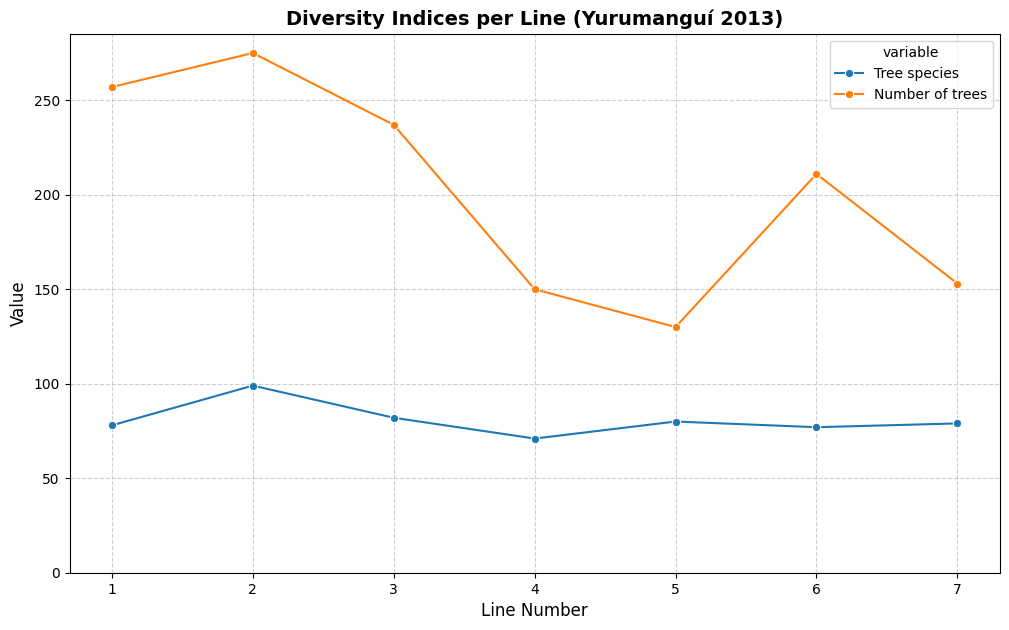

In [68]:
plt.figure(figsize=(12, 7))
sns.lineplot(data=div_per_line.melt(id_vars='Line Number', value_vars=[ "Tree species", "Number of trees"]), x='Line Number', y='value', hue='variable', marker='o')
plt.title("Diversity Indices per Line (Yurumanguí 2013)", fontsize=14, fontweight='bold')
plt.xlabel("Line Number", fontsize=12) 
plt.ylabel("Value", fontsize=12)
plt.ylim(bottom=0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

C:\Users\migue\AppData\Local\Temp\ipykernel_21232\675746972.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group[idx].values for name, group in div_per_line.groupby('Line Number')]
C:\Users\migue\AppData\Local\Temp\ipykernel_21232\675746972.py:43: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x='Line Number', y=idx, data=div_per_line, palette=div_dict, marker='o')
C:\Users\migue\AppData\Local\Temp\ipykernel_21232\675746972.py:43: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x='Line Number', y=idx, data=div_per_line, palette=div_dict, marker='o')
C:\Users\migue\AppData\Local\Temp\ipykernel_21232\675746972.py:43: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  s


--- Kruskal-Wallis Summary ---
             Index  H-statistic  p-value
0   Margalef Index          6.0  0.42319
1  Menhinick Index          6.0  0.42319
2    Shannon Index          6.0  0.42319
3     Pielou Index          6.0  0.42319
4    Simpson Index          6.0  0.42319


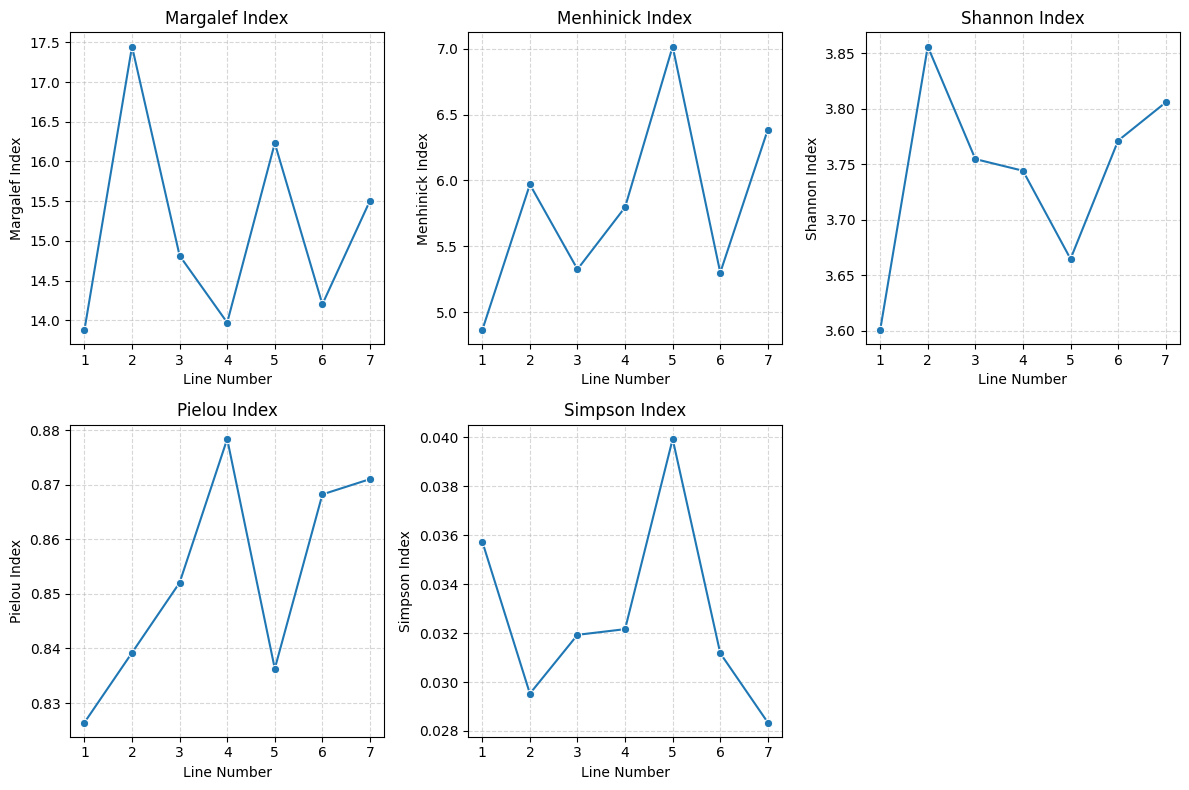

In [64]:
# Note: Based on your image, I'll assume 'Line Number' refers to your different forest sites/types.
# Ensure you have multiple rows (samples) for each site to make the test valid.
div_dict = {
    'Margalef': '#1f77b4',   # Blue
    'Menhinick': '#ff7f0e',  # Orange
    'Shannon': '#2ca02c',    # Green
    'Pielou': '#d62728',     # Red
    'Simpson': '#9467bd',    # Purple
}

indices = [
    'Margalef Index', 'Menhinick Index', 
    'Shannon Index', 'Pielou Index', 'Simpson Index'
]

# 2. Run Kruskal-Wallis for each Index
results = []

for idx in indices:
    # We group by 'Line Number' and create a list of data arrays for each group
    groups = [group[idx].values for name, group in div_per_line.groupby('Line Number')]
    
    # Kruskal-Wallis Test
    stat, p = kruskal(*groups)
    
    results.append({'Index': idx, 'H-statistic': stat, 'p-value': p})
    
    # 3. Post-hoc Analysis (Dunn's Test) if significant
    if p < 0.05:
        print(f"\n Significant differences found in {idx} (p={p:.4f})")
        posthoc = sp.posthoc_dunn(df, val_col=idx, group_col='Line Number', p_adjust='bonferroni')
        print(posthoc)

# Display Summary
results_df = pd.DataFrame(results)
print("\n--- Kruskal-Wallis Summary ---")
print(results_df)

# 4. Visualization
plt.figure(figsize=(12, 8))
for i, idx in enumerate(indices, 1):
    plt.subplot(2, 3, i)
    sns.lineplot(x='Line Number', y=idx, data=div_per_line, palette=div_dict, marker='o')
    plt.title(idx)
    plt.xticks()
    plt.grid(True, linestyle='--', alpha=0.5)
    

plt.tight_layout()
plt.show()